In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [2]:
df=pd.read_csv("/content/FINANCIAL SENTIMENT ANALYSIS.csv")
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [4]:
df.shape

(5842, 2)

In [5]:
df.isnull().sum()

,0
Sentence,0
Sentiment,0


In [6]:
df['Sentiment'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

EDA-CLASS DISTRIBUTION

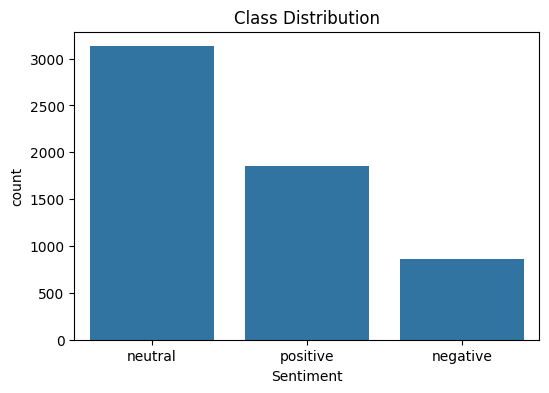

Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64
Sentiment
neutral     53.577542
positive    31.701472
negative    14.720986
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df, order=df['Sentiment'].value_counts().index)
plt.title('Class Distribution')
plt.show()

print(df['Sentiment'].value_counts())
print(df['Sentiment'].value_counts(normalize=True) * 100)

EDA-SENTENCE LENGTH DISTRIBUTION

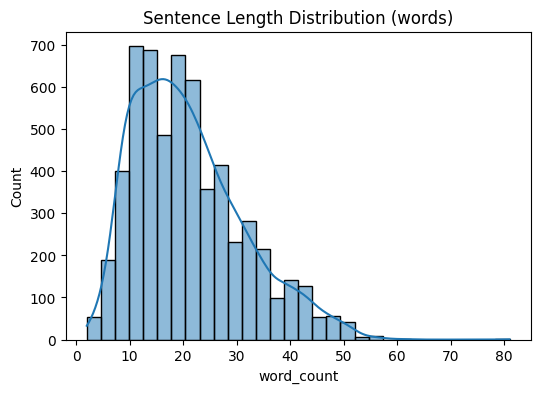

,count,mean,std,min,25%,50%,75%,max
Sentiment,,,,,,,,
negative,860.0,19.263953,10.260353,2.0,11.0,17.0,25.0,56.0
neutral,3130.0,22.133866,10.002699,2.0,15.0,21.0,28.0,81.0
positive,1852.0,19.904968,10.603438,2.0,11.0,18.0,27.0,57.0


In [8]:
df['word_count'] = df['Sentence'].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title('Sentence Length Distribution (words)')
plt.show()

df.groupby('Sentiment')['word_count'].describe()

ENCODE TARGET LABELS

In [9]:
unique_sentiments = df['Sentiment'].unique()
sentiment_numbers = {}
i = 0
for s in unique_sentiments:
    sentiment_numbers[s] = i
    i += 1

df['Sentiment_encoded'] = df['Sentiment'].map(sentiment_numbers)
print(sentiment_numbers)
df.head()

{'positive': 0, 'negative': 1, 'neutral': 2}


,Sentence,Sentiment,word_count,Sentiment_encoded
0,The GeoSolutions technology will leverage Bene...,positive,32,0
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,11,1
2,"For the last quarter of 2010 , Componenta 's n...",positive,39,0
3,According to the Finnish-Russian Chamber of Co...,neutral,20,2
4,The Swedish buyout firm has sold its remaining...,neutral,23,2


Text cleaning — lowercase + punctuation (keeping numbers,since $ amounts matter in financial text)

In [10]:
import string

df['clean_text'] = df['Sentence'].apply(lambda x: x.lower())

def remove_punc(txt):
    return txt.translate(str.maketrans('', '', string.punctuation))

df['clean_text'] = df['clean_text'].apply(remove_punc)
df.head()

,Sentence,Sentiment,word_count,Sentiment_encoded,clean_text
0,The GeoSolutions technology will leverage Bene...,positive,32,0,the geosolutions technology will leverage bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,11,1,esi on lows down 150 to 250 bk a real possibility
2,"For the last quarter of 2010 , Componenta 's n...",positive,39,0,for the last quarter of 2010 componenta s net...
3,According to the Finnish-Russian Chamber of Co...,neutral,20,2,according to the finnishrussian chamber of com...
4,The Swedish buyout firm has sold its remaining...,neutral,23,2,the swedish buyout firm has sold its remaining...


Remove stopwords

In [11]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(txt):
    words = txt.split()
    cleaned = [w for w in words if w not in stop_words]
    return " ".join(cleaned)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Sentence,Sentiment,word_count,Sentiment_encoded,clean_text
0,The GeoSolutions technology will leverage Bene...,positive,32,0,geosolutions technology leverage benefon gps s...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,11,1,esi lows 150 250 bk real possibility
2,"For the last quarter of 2010 , Componenta 's n...",positive,39,0,last quarter 2010 componenta net sales doubled...
3,According to the Finnish-Russian Chamber of Co...,neutral,20,2,according finnishrussian chamber commerce majo...
4,The Swedish buyout firm has sold its remaining...,neutral,23,2,swedish buyout firm sold remaining 224 percent...


Train-test split

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df['clean_text'], df['Sentiment_encoded'], test_size=0.20, random_state=42, stratify=df['Sentiment_encoded']
)
#Note: stratify keeps the same class proportions in train and test — important given the imbalance you saw.

Vectorization — BoW and TF-IDF

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vectorizer = CountVectorizer()
x_train_bow = bow_vectorizer.fit_transform(x_train)
x_test_bow = bow_vectorizer.transform(x_test)

tfidf_vectorizer = TfidfVectorizer()
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

Naive Bayes — BoW and TF-IDF

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_bow = MultinomialNB()
nb_bow.fit(x_train_bow, y_train)
pred_nb_bow = nb_bow.predict(x_test_bow)
print("NB + BoW Accuracy:", accuracy_score(y_test, pred_nb_bow))
print("NB+BoW classification report:\n",classification_report(y_test, pred_nb_bow))

nb_tfidf = MultinomialNB()
nb_tfidf.fit(x_train_tfidf, y_train)
pred_nb_tfidf = nb_tfidf.predict(x_test_tfidf)
print("NB + TFIDF Accuracy:", accuracy_score(y_test, pred_nb_tfidf))
print("NB+TFIDF classification report:\n",classification_report(y_test, pred_nb_tfidf))

NB + BoW Accuracy: 0.6775021385799829
NB+BoW classification report:
               precision    recall  f1-score   support

           0       0.73      0.62      0.67       371
           1       0.34      0.26      0.29       172
           2       0.72      0.83      0.77       626

    accuracy                           0.68      1169
   macro avg       0.59      0.57      0.58      1169
weighted avg       0.66      0.68      0.67      1169

NB + TFIDF Accuracy: 0.649272882805817
NB+TFIDF classification report:
               precision    recall  f1-score   support

           0       0.73      0.40      0.52       371
           1       0.75      0.02      0.03       172
           2       0.63      0.97      0.76       626

    accuracy                           0.65      1169
   macro avg       0.70      0.46      0.44      1169
weighted avg       0.68      0.65      0.58      1169



 Logistic Regression — BoW and TF-IDF

In [15]:
from sklearn.linear_model import LogisticRegression

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(x_train_bow, y_train)
pred_lr_bow = lr_bow.predict(x_test_bow)
print("LR + BoW Accuracy:", accuracy_score(y_test, pred_lr_bow))
print("LR+BoW classification report:\n",classification_report(y_test, pred_lr_bow))

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(x_train_tfidf, y_train)
pred_lr_tfidf = lr_tfidf.predict(x_test_tfidf)
print("LR + TFIDF Accuracy:", accuracy_score(y_test, pred_lr_tfidf))
print("LR+TFIDF classification report:\n",classification_report(y_test, pred_lr_tfidf))

LR + BoW Accuracy: 0.6501283147989735
LR+BoW classification report:
               precision    recall  f1-score   support

           0       0.78      0.67      0.72       371
           1       0.18      0.14      0.16       172
           2       0.68      0.78      0.72       626

    accuracy                           0.65      1169
   macro avg       0.55      0.53      0.53      1169
weighted avg       0.64      0.65      0.64      1169

LR + TFIDF Accuracy: 0.6723695466210436
LR+TFIDF classification report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67       371
           1       0.25      0.09      0.13       172
           2       0.68      0.88      0.76       626

    accuracy                           0.67      1169
   macro avg       0.56      0.52      0.52      1169
weighted avg       0.64      0.67      0.64      1169



Confusion matrix

In [16]:
target_names = list(sentiment_numbers.keys())


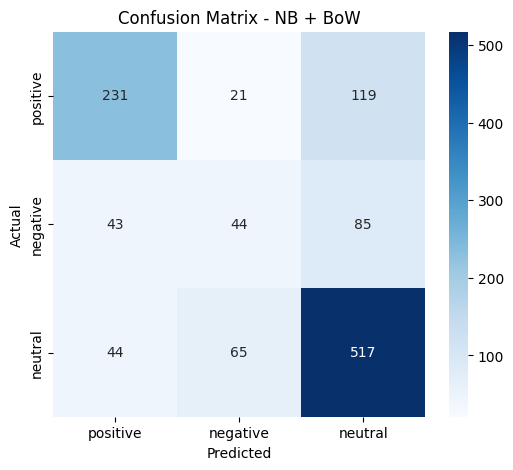

In [17]:
cm = confusion_matrix(y_test, pred_nb_bow)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - NB + BoW')
plt.show()

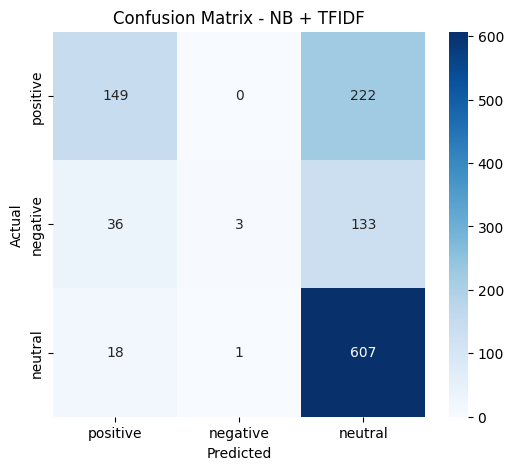

In [18]:
cm = confusion_matrix(y_test, pred_nb_tfidf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - NB + TFIDF')
plt.show()

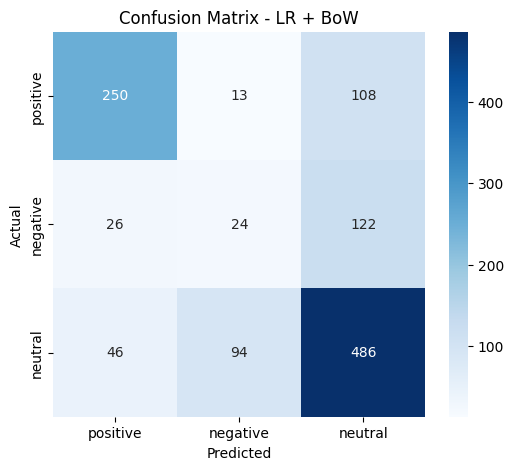

In [19]:
cm = confusion_matrix(y_test, pred_lr_bow)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LR + BoW')
plt.show()

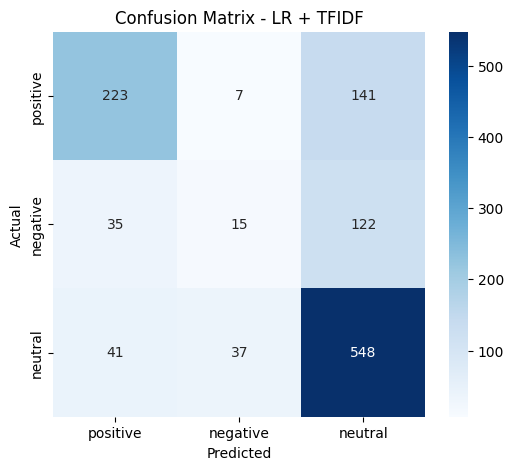

In [20]:
cm = confusion_matrix(y_test, pred_lr_tfidf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LR + TFIDF')
plt.show()

Logistic Regression(balanced) — BoW and TF-IDF

In [21]:
lr_balanced_bow = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced_bow.fit(x_train_bow, y_train)
pred_lr_balanced_bow = lr_balanced_bow.predict(x_test_bow)

print("LR (balanced) + BoW Accuracy:", accuracy_score(y_test, pred_lr_balanced_bow))
print(classification_report(y_test, pred_lr_balanced_bow, target_names=target_names))

LR (balanced) + BoW Accuracy: 0.6561163387510693
              precision    recall  f1-score   support

    positive       0.75      0.68      0.72       371
    negative       0.27      0.30      0.28       172
     neutral       0.72      0.74      0.73       626

    accuracy                           0.66      1169
   macro avg       0.58      0.57      0.58      1169
weighted avg       0.67      0.66      0.66      1169



In [22]:
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(x_train_tfidf, y_train)
pred_lr_balanced = lr_balanced.predict(x_test_tfidf)

print("LR (balanced) + TFIDF Accuracy:", accuracy_score(y_test, pred_lr_balanced))
print(classification_report(y_test, pred_lr_balanced, target_names=target_names))

LR (balanced) + TFIDF Accuracy: 0.679213002566296
              precision    recall  f1-score   support

    positive       0.72      0.68      0.70       371
    negative       0.37      0.51      0.43       172
     neutral       0.78      0.73      0.75       626

    accuracy                           0.68      1169
   macro avg       0.62      0.64      0.63      1169
weighted avg       0.70      0.68      0.69      1169



Confusion matrix — LR (balanced) + BoW

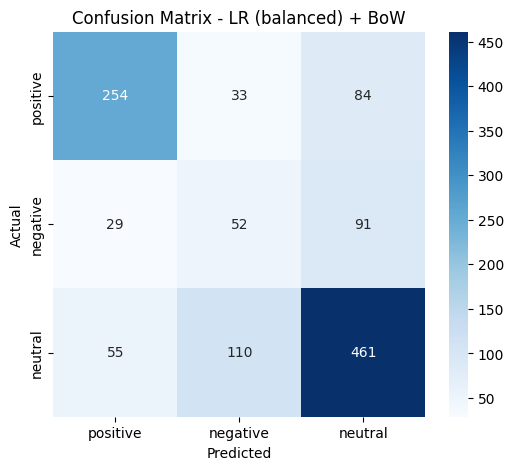

In [23]:
cm = confusion_matrix(y_test, pred_lr_balanced_bow)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LR (balanced) + BoW')
plt.show()

Confusion matrix — LR (balanced) + TF-IDF

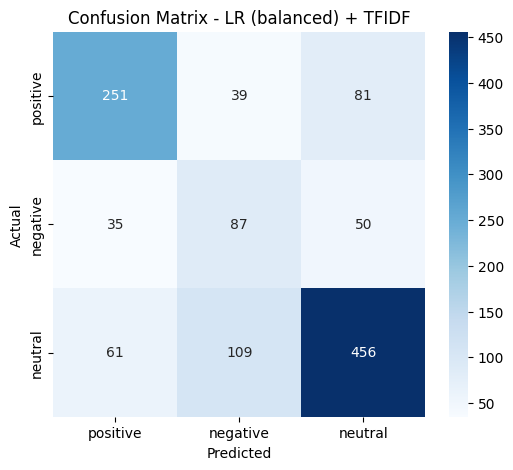

In [24]:
cm = confusion_matrix(y_test, pred_lr_balanced)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LR (balanced) + TFIDF')
plt.show()

FINAL COMPARISON TABLE

In [25]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# store each model's predictions here
results = {
    'NB + BoW': pred_nb_bow,
    'NB + TFIDF': pred_nb_tfidf,
    'LR + BoW': pred_lr_bow,
    'LR + TFIDF': pred_lr_tfidf,
    'LR (balanced) + BoW': pred_lr_balanced_bow,
    'LR (balanced) + TFIDF': pred_lr_balanced
}

summary_rows = []

for model_name, preds in results.items():
    acc = accuracy_score(y_test, preds)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, preds, average=None, labels=[0, 1, 2]
    )
    macro_f1 = f1.mean()

    # class 1 = negative (based on your sentiment_numbers mapping)
    negative_recall = recall[1]
    negative_f1 = f1[1]

    summary_rows.append({
        'Model': model_name,
        'Accuracy': round(acc, 3),
        'Macro F1': round(macro_f1, 3),
        'Negative Recall': round(negative_recall, 3),
        'Negative F1': round(negative_f1, 3)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by='Macro F1', ascending=False).reset_index(drop=True)
summary_df

,Model,Accuracy,Macro F1,Negative Recall,Negative F1
0,LR (balanced) + TFIDF,0.679,0.626,0.506,0.428
1,NB + BoW,0.678,0.577,0.256,0.291
2,LR (balanced) + BoW,0.656,0.577,0.302,0.283
3,LR + BoW,0.650,0.535,0.140,0.158
4,LR + TFIDF,0.672,0.519,0.087,0.130
5,NB + TFIDF,0.649,0.439,0.017,0.034


#LR (balanced) + TFIDF is the clear winner.

HYPERPARAMETER TUNING


In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    scoring='f1_macro',
    cv=5
)

grid_search.fit(x_train_tfidf, y_train)

print("Best C:", grid_search.best_params_)
print("Best CV macro F1:", grid_search.best_score_)

Best C: {'C': 1}
Best CV macro F1: 0.6089328788228228


GIVES C=1 is the best, i.e, no use of hyperparameter tuning

In [27]:
best_lr = grid_search.best_estimator_
pred_best_lr = best_lr.predict(x_test_tfidf)

print("Tuned LR (balanced) + TFIDF Accuracy:", accuracy_score(y_test, pred_best_lr))
print(classification_report(y_test, pred_best_lr, target_names=target_names))

Tuned LR (balanced) + TFIDF Accuracy: 0.679213002566296
              precision    recall  f1-score   support

    positive       0.72      0.68      0.70       371
    negative       0.37      0.51      0.43       172
     neutral       0.78      0.73      0.75       626

    accuracy                           0.68      1169
   macro avg       0.62      0.64      0.63      1169
weighted avg       0.70      0.68      0.69      1169



Comment:

>This project applied classical NLP and machine learning techniques to classify financial news sentences into three sentiment classes: positive, negative, and neutral. The dataset showed clear class imbalance (53.6% neutral, 31.7% positive, only 14.7% negative), which shaped the entire analysis.

>Two vectorization methods (Bag of Words and TF-IDF) were combined with two baseline models (Naive Bayes and Logistic Regression), giving four initial models. While their accuracy scores looked reasonably close (0.65–0.68), examining macro F1 and per-class recall revealed a more important problem: all four models performed poorly on the minority negative class, with recall as low as 0.02–0.30. Accuracy alone was hiding this weakness, since it is dominated by the majority neutral class.

>To address this, class_weight='balanced' was applied to Logistic Regression. This improved performance across the board — not just for the negative class, but on accuracy and macro F1 as well — with LR (balanced) + TF-IDF emerging as the strongest model: 0.679 accuracy, 0.63 macro F1, and 0.51 recall on the negative class, nearly double the best result from any unbalanced model.

>To confirm this model was genuinely well-fit rather than left half-tuned, hyperparameter tuning of C was performed via GridSearchCV (5-fold cross-validation, optimizing macro F1) on the balanced LR + TF-IDF model. The search returned C=1, the same default value already in use — confirming the model was already at its optimal regularization strength for this dataset, rather than an untested assumption. While the result didn't change the fitted model, it validated that the choice was genuinely optimal and not just a lucky default.

>Final model: Logistic Regression with class_weight='balanced' and TF-IDF (C=1) — selected not for accuracy alone, but because it was the only model that meaningfully improved detection of the minority negative class without sacrificing overall performance. Hyperparameter tuning confirmed this as a validated, stable choice rather than an arbitrary stopping point.

DEPLOYMENT

Save your trained model and vectorizer

In [28]:
import joblib

joblib.dump(lr_balanced, 'sentiment_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

# also save your label mapping so the app can decode predictions
import json
with open('sentiment_numbers.json', 'w') as f:
    json.dump(sentiment_numbers, f)